# PROJECT: College Admission Predictor

In [33]:
# importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
# loading the dataset
df = pd.read_csv('admission_predict.csv')

In [35]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [36]:
print(df.info())
print("="*100)
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB
None
(500, 9)


In [37]:
print(df.describe().T)
print("="*100)
print(df.columns)

                   count       mean         std     min       25%     50%  \
Serial No.         500.0  250.50000  144.481833    1.00  125.7500  250.50   
GRE Score          500.0  316.47200   11.295148  290.00  308.0000  317.00   
TOEFL Score        500.0  107.19200    6.081868   92.00  103.0000  107.00   
University Rating  500.0    3.11400    1.143512    1.00    2.0000    3.00   
SOP                500.0    3.37400    0.991004    1.00    2.5000    3.50   
LOR                500.0    3.48400    0.925450    1.00    3.0000    3.50   
CGPA               500.0    8.57644    0.604813    6.80    8.1275    8.56   
Research           500.0    0.56000    0.496884    0.00    0.0000    1.00   
Chance of Admit    500.0    0.72174    0.141140    0.34    0.6300    0.72   

                      75%     max  
Serial No.         375.25  500.00  
GRE Score          325.00  340.00  
TOEFL Score        112.00  120.00  
University Rating    4.00    5.00  
SOP                  4.00    5.00  
LOR          

In [38]:
# returns true or a column having null values, else false
df.isnull().any()

,0
Serial No.,False
GRE Score,False
TOEFL Score,False
University Rating,False
SOP,False
LOR,False
CGPA,False
Research,False
Chance of Admit,False


In [39]:
# renaming the columns with appropriate names
df = df.rename(columns={'GRE Score': 'GRE', 'TOEFL Score': 'TOEFL', 'LOR ': 'LOR', 'Chance of Admit ': 'Probability'})
df.head()

,Serial No.,GRE,TOEFL,University Rating,SOP,LOR,CGPA,Research,Probability
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


## Data Visualization

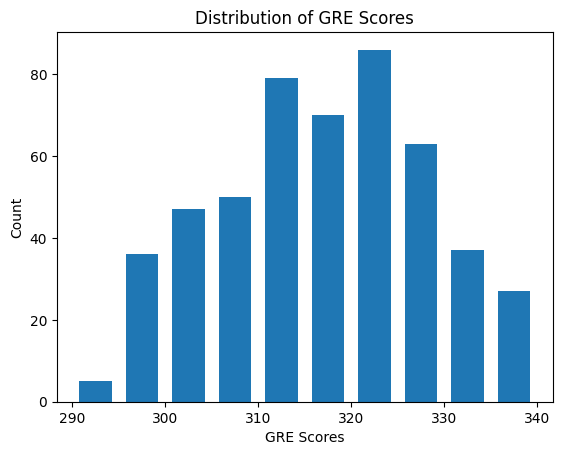

In [40]:
# visualizing the feature GRE
fig = plt.hist(df['GRE'], rwidth=0.7)
plt.title("Distribution of GRE Scores")
plt.xlabel('GRE Scores')
plt.ylabel('Count')
plt.show()

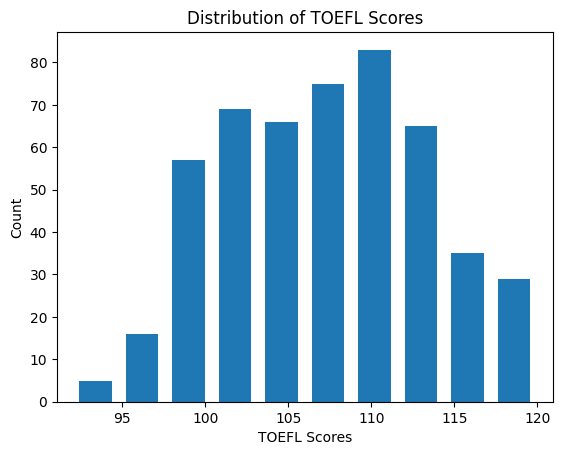

In [41]:
# visualizing the feature TOEFL
fig = plt.hist(df['TOEFL'], rwidth=0.7)
plt.title("Distribution of TOEFL Scores")
plt.xlabel('TOEFL Scores')
plt.ylabel('Count')
plt.show()

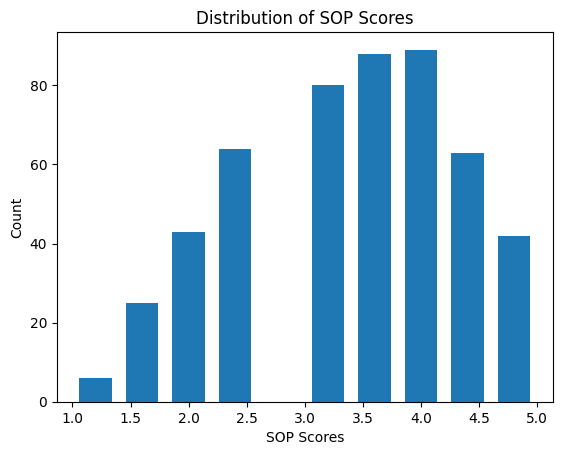

In [42]:
# visualizing the feature SOP
fig = plt.hist(df['SOP'], rwidth=0.7)
plt.title("Distribution of SOP Scores")
plt.xlabel('SOP Scores')
plt.ylabel('Count')
plt.show()

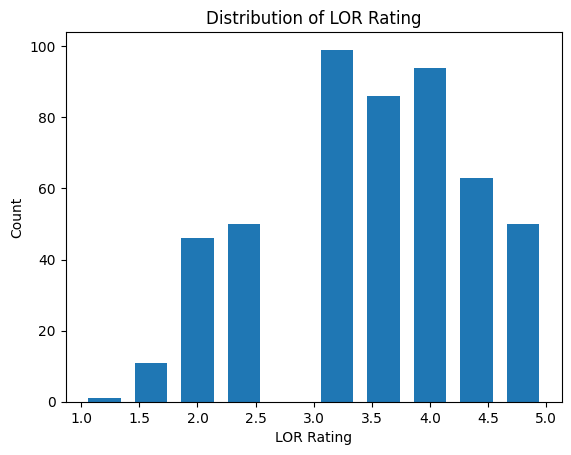

In [43]:
# visualizing the feature LOR
fig = plt.hist(df['LOR'], rwidth=0.7)
plt.title("Distribution of LOR Rating")
plt.xlabel('LOR Rating')
plt.ylabel('Count')
plt.show()

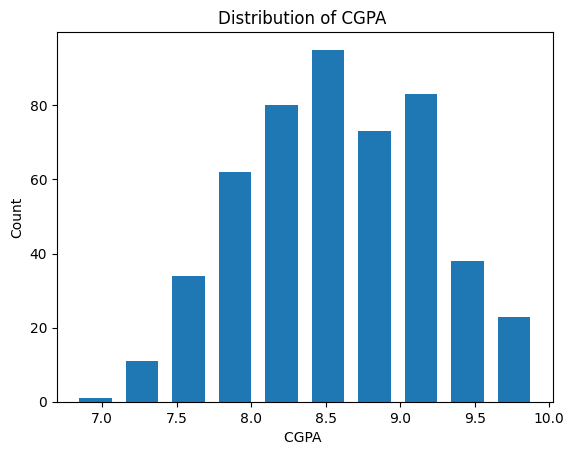

In [44]:
# visualizing the feature CGPA
fig = plt.hist(df['CGPA'], rwidth=0.7)
plt.title("Distribution of CGPA ")
plt.xlabel('CGPA ')
plt.ylabel('Count')
plt.show()

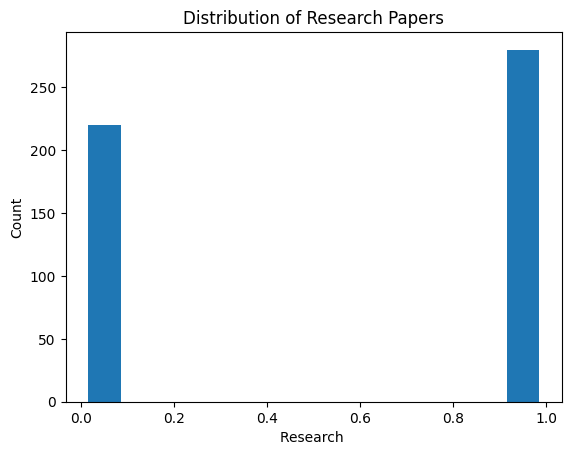

In [45]:
# visualizing the feature Research
fig = plt.hist(df['Research'], rwidth=0.7)
plt.title("Distribution of Research Papers")
plt.xlabel('Research ')
plt.ylabel('Count')
plt.show()

## Data Cleaning

In [46]:
# # Removing the 'serial no' column because we dont have any use with this column in our project.
df.drop('Serial No.', axis='columns', inplace=True)
df.head()

,GRE,TOEFL,University Rating,SOP,LOR,CGPA,Research,Probability
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [47]:
df_copy = df.copy(deep=True)
df_copy[['GRE', 'TOEFL', 'University Rating', 'SOP', 'LOR', 'CGPA']] = df_copy[['GRE', 'TOEFL', 'University Rating', 'SOP', 'LOR', 'CGPA']].replace(0, np.nan)
df_copy.isnull().sum()

,0
GRE,0
TOEFL,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Probability,0


## Model Building

In [48]:
# Splitting the dataset in features and label
X = df_copy.drop('Probability', axis='columns')
y = df_copy['Probability']

In [49]:
# Using GridSearchCV to find the best algorithm for this problem
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

In [50]:
# Creating a function to calculate best model for this problem
def find_best_model(X, y):
    models = {
        'linear_regression': {
            'model': LinearRegression(),
            'parameters': {
                # 'normalize': [True,False]  # Removed 'normalize' parameter
            }
        },

        'lasso': {
            'model': Lasso(),
            'parameters': {
                'alpha': [1,2],
                'selection': ['random', 'cyclic']
            }
        },

        'svr': {
            'model': SVR(),
            'parameters': {
                'gamma': ['auto','scale']
            }
        },

        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'parameters': {
                'criterion': ['squared_error', 'friedman_mse'],
                'splitter': ['best', 'random']
            }
        },

        'random_forest': {
            'model': RandomForestRegressor(criterion='squared_error'),
            'parameters': {
                'n_estimators': [5,10,15,20]
            }
        },

        'knn': {
            'model': KNeighborsRegressor(algorithm='auto'),
            'parameters': {
                'n_neighbors': [2,5,10,20]
            }
        }
    }

    scores = []
    for model_name, model_params in models.items():
        gs = GridSearchCV(model_params['model'], model_params['parameters'], cv=5, return_train_score=False)
        gs.fit(X, y)
        scores.append({
            'model': model_name,
            'best_parameters': gs.best_params_,
            'score': gs.best_score_
        })

    return pd.DataFrame(scores, columns=['model','best_parameters','score'])

find_best_model(X, y)

,model,best_parameters,score
0,linear_regression,{},0.810802
1,lasso,"{'alpha': 1, 'selection': 'random'}",0.215088
2,svr,{'gamma': 'scale'},0.654099
3,decision_tree,"{'criterion': 'friedman_mse', 'splitter': 'ran...",0.584184
4,random_forest,{'n_estimators': 20},0.769258
5,knn,{'n_neighbors': 20},0.723012


In [51]:
# Using cross_val_score for gaining highest accuracy
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LinearRegression(), X, y, cv=5)
print('Highest Accuracy : {:.3f}%'.format(sum(scores)*100/len(scores)))

Highest Accuracy : 81.080%


In [52]:
# Splitting the dataset into train and test samples
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=5)
print(len(X_train), len(X_test))

400 100


In [53]:
# Creating Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)


0.821478736588966

In [54]:
# Prediction 1
# Input in the form : GRE, TOEFL, University Rating, SOP, LOR, CGPA, Research
print('Chance of getting into UCLA is {}%'.format(round(model.predict([[337, 118, 4, 4.5, 4.5, 9.65, 0]])[0]*100, 3)))

Chance of getting into UCLA is 92.855%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [55]:
# Prediction 2
# Input in the form : GRE, TOEFL, University Rating, SOP, LOR, CGPA, Research
print('Chance of getting into UCLA is {}%'.format(round(model.predict([[320, 113, 2, 2.0, 2.5, 8.64, 1]])[0]*100, 3)))

Chance of getting into UCLA is 73.627%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
